<a href="https://colab.research.google.com/github/NickPowell04/IT480-FA26/blob/main/Powell_Nick_Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Nick Powell*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [ ]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [ ]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [ ]:
# Your exploration here

import collections
counts = collections.Counter()
for _, labels in train_raw_fire:
    counts.update(labels.numpy().tolist())
print(counts, class_names_fire)

Counter({0: 538, 1: 162}) ['fire_images', 'non_fire_images']


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The dataset seems pretty imbalanced, with 538 classified as fire_images, and 162 classified as non_fire_images. A model that always predicts fire would hit around 77% accuracy, so accuracy alone can be misleading. I'll compare my results to that baseline and rely on the confusion matrix to see how well the model handles the minority non-fire class. The split is random, so the test set may not have the same fire/non-fire mix as the full dataset. It's also small, so a few misclassified images could change my results a lot.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [ ]:
# Preprocess the data here

def prep(images, labels):
    return preprocess_input(images), labels

train_fire = train_raw_fire.map(prep)
val_fire = val_raw_fire.map(prep)
test_fire = test_raw_fire.map(prep)

In [ ]:
# Build your model here

base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)
model_fire = Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Compile your model here

model_fire.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

## 1D — Train and Evaluate

In [ ]:
# Train your model here

history_fire = model_fire.fit(train_fire, validation_data=val_fire, epochs=5)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 911ms/step - accuracy: 0.6671 - loss: 0.6661 - val_accuracy: 0.7482 - val_loss: 0.5598
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 664ms/step - accuracy: 0.9029 - loss: 0.2530 - val_accuracy: 0.9137 - val_loss: 0.2142
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 556ms/step - accuracy: 0.9571 - loss: 0.1526 - val_accuracy: 0.9353 - val_loss: 0.1765
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 638ms/step - accuracy: 0.9686 - loss: 0.1174 - val_accuracy: 0.9712 - val_loss: 0.1240
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 609ms/step - accuracy: 0.9743 - loss: 0.0968 - val_accuracy: 0.9712 - val_loss: 0.0976


In [ ]:
# Report validation and test accuracy here

val_loss, val_acc = model_fire.evaluate(val_fire)
test_loss, test_acc = model_fire.evaluate(test_fire)
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - accuracy: 0.9568 - loss: 0.1139
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.9750 - loss: 0.0923
Validation accuracy: 0.9568
Test accuracy: 0.9750


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

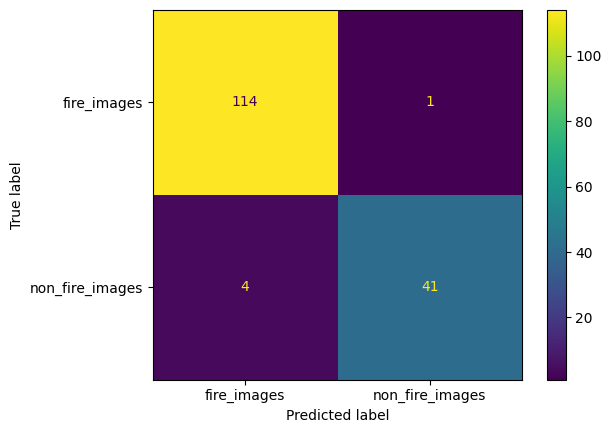

In [ ]:
# Build your confusion matrix here

y_true, y_prob = [], []
for images, labels in test_fire:
    y_prob.extend(model_fire.predict(images, verbose=0).ravel())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = (np.array(y_prob) > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names_fire).plot()
plt.show()

*Your answer:* A false negative is much more costly than a false positive. A missed fire can lead to property damage, injury, or loss of life, while a false alarm usually only costs a little time to check. My confusion matrix showed 1 missed fire and 4 false alarms, so the model already leans toward predicting fire. Still, the one missed fire is the error that matters most. In practice, I would not use the default 0.5 threshold. My model outputs the probability of non-fire, so I would require a higher value (for example, 0.7) before predicting "non-fire." This catches more real fires at the cost of more false alarms, which is an acceptable trade.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [ ]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['SeaLake', 'HerbaceousVegetation', 'Forest', 'PermanentCrop', 'AnnualCrop', 'Industrial', 'Residential', 'Pasture', 'River', 'Highway']


In [ ]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [ ]:
# Preprocess the data here

train_sat = train_raw_sat.map(prep)
val_sat = val_raw_sat.map(prep)
test_sat = test_raw_sat.map(prep)

In [ ]:
# Build your model here

base_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation="softmax")(x)
model_sat = Model(inputs, outputs)

In [ ]:
# Compile your model here

model_sat.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

## 2C — Train and Evaluate

In [ ]:
# Train your model here

history_sat = model_sat.fit(train_sat, validation_data=val_sat, epochs=5)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 51s 75ms/step - accuracy: 0.8773 - loss: 0.3721 - val_accuracy: 0.9326 - val_loss: 0.2144
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.9325 - loss: 0.1962 - val_accuracy: 0.9403 - val_loss: 0.1883
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.9466 - loss: 0.1599 - val_accuracy: 0.9381 - val_loss: 0.1815
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9534 - loss: 0.1388 - val_accuracy: 0.9415 - val_loss: 0.1806
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.9606 - loss: 0.1220 - val_accuracy: 0.9410 - val_loss: 0.1759


In [ ]:
# Report validation and test accuracy here

val_loss, val_acc = model_sat.evaluate(val_sat)
test_loss, test_acc = model_sat.evaluate(test_sat)
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9398 - loss: 0.1794
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9409 - loss: 0.1751
Validation accuracy: 0.9398
Test accuracy: 0.9409


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

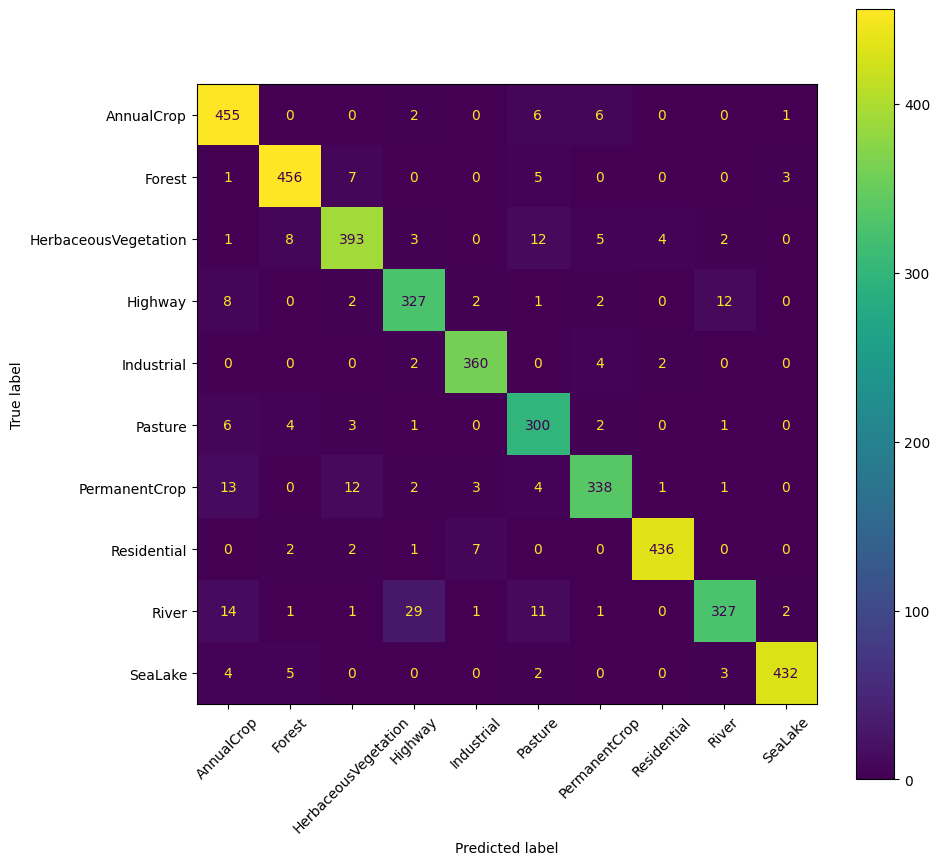

In [ ]:
# Build your confusion matrix here

y_true, y_pred = [], []
for images, labels in test_sat:
    probs = model_sat.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm, display_labels=class_names_sat).plot(ax=ax, xticks_rotation=45)
plt.show()

*Your answer:* The most confused classes were River and Highway (29 rivers predicted as highways, 12 the other way). Next were the vegetation classes: PermanentCrop, AnnualCrop, HerbaceousVegetation, and Pasture. This makes visual sense. Rivers and highways are both long, thin features running through the landscape, and the crop and vegetation classes are all green, textured fields that look similar from above at low resolution. Distinct classes like SeaLake and Residential were rarely confused.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |0.9568|0.9398|
| Test Accuracy |0.9750|0.9409|

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

The Fire dataset is the closer match to ImageNet, since it contains ordinary ground-level photos, while EuroSAT's top-down satellite tiles are the bigger mismatch. My model results support this: Fire reached 97.5% test accuracy versus 94.1% for EuroSAT, and EuroSAT's errors were mostly between classes that look alike from above, like River and Highway. The gap isn't purely domain mismatch, though, since EuroSAT also has 10 classes instead of 2, which makes it a harder task. Fine-tuning would likely matter more for EuroSAT. Fire is already at ~97.5% and its images resemble what the base was trained on, so there's little left to gain. EuroSAT has more room for improvement, and its frozen features were never trained on top-down textures, so letting later layers adapt could help separate confusing pairs like River and Highway.


---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The Fire dataset was imbalanced, about 77% fire and 23% non-fire, so accuracy alone could be misleading and I compared my results to the 77% baseline and used the confusion matrix to check each class. Because the split was random and the test set small, I also treated the numbers as somewhat noisy. In Part 1 I used one sigmoid unit with binary cross-entropy because there were two classes and only one probability was needed. In Part 2 I used ten softmax units with sparse categorical cross-entropy because each image belongs to exactly one of ten classes, so the outputs must compete and sum to 1. My results show that a pretrained model's usefulness depends on more than the model itself: the same MobileNetV2 reached 97.5% on Fire but 94.1% on EuroSAT, whose satellite images are a worse match for ImageNet. Both results were still well above their baselines, so the pretrained features transfer, but how well depends on how closely the original training matches the new task.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.